# RSO-537: Test LSSTCam FAM Unpaired pipelines, in preparation for RSO-462
https://rubinobs.atlassian.net/browse/RSO-537

Try the unpaired pipelines 

ts_wep : 17.1.0   donut_viz : 4.1.0   lsst_distrib: 2026_19 




there are two versions of unnpaired pipelines in `pipelines/production/lsstcam_usdf`:

* if running from the scratch, use  `lsstCamScienceSensorUSDF_UnpairedDanish.yaml` 

* if running FAM paired first, use `lsstCamScienceSensorUSDF_UnpairedDanishExtra.yaml` and 
`lsstCamScienceSensorUSDF_UnpairedDanishIntra.yaml`,   because they are set up to reuse the donut stamps from the paired pipeline (donutStampsIntra and donutStampsExtra) to save time and compute

## 1) Running from scratch: use `lsstCamScienceSensorUSDF_UnpairedDanish.yaml` 

In [4]:
#Well, try them out!  First try running the full version on a tiny subset of data 

from lsst.daf import butler as dafButler
butler = dafButler.Butler('/repo/main')
day_obs = 20260404

refs = list(butler.registry.queryDatasets(
    'raw',
    collections=['LSSTCam/defaults'], day_obs = day_obs,
    where=f"instrument='LSSTCam' \
    and exposure.observation_type in ('cwfs') \
    and detector=91 and exposure.seq_num in (193,194) \
    and exposure.day_obs in ({day_obs})  "
).expanded())




In [5]:
len(refs)

2

check the outputs: 

In [10]:
collection = 'u/scichris/test_FAM_unpaired_20260404_det91'
butler = dafButler.Butler('/repo/main')
refs = list(butler.registry.queryDatasets(
    'post_isr_image',
    collections=[collection], day_obs = day_obs,
    where=f"instrument='LSSTCam'").expanded())



In [11]:
refs

[DatasetRef(DatasetType('post_isr_image', {band, instrument, day_obs, detector, group, physical_filter, exposure}, Exposure), {instrument: 'LSSTCam', detector: 91, exposure: 2026040400193, band: 'i', day_obs: 20260404, group: '2026-04-05T02:15:55.775#1', physical_filter: 'i_39'}, run='u/scichris/test_FAM_unpaired_20260404_det91/20260512T225332Z', id=019e1e65-de92-784d-945b-75b94476b609),
 DatasetRef(DatasetType('post_isr_image', {band, instrument, day_obs, detector, group, physical_filter, exposure}, Exposure), {instrument: 'LSSTCam', detector: 91, exposure: 2026040400194, band: 'i', day_obs: 20260404, group: '2026-04-05T02:15:55.775#1', physical_filter: 'i_39'}, run='u/scichris/test_FAM_unpaired_20260404_det91/20260512T225332Z', id=019e1e65-de92-7466-99b5-8766b72ba09d)]

Based on each image, we detect donuts, and create donut catalog: 

In [ ]:

refs = list(butler.registry.queryDatasets(
    'donutTable',
    collections=[collection], day_obs = day_obs,
    where=f"instrument='LSSTCam'").expanded())



In [22]:
refs

[DatasetRef(DatasetType('donutTable', {band, instrument, day_obs, detector, physical_filter, visit}, AstropyQTable), {instrument: 'LSSTCam', detector: 91, visit: 2026040400193, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_unpaired_20260404_det91/20260512T225332Z', id=019e1e65-deb1-7116-bc95-f6d53eb5c03b),
 DatasetRef(DatasetType('donutTable', {band, instrument, day_obs, detector, physical_filter, visit}, AstropyQTable), {instrument: 'LSSTCam', detector: 91, visit: 2026040400194, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_unpaired_20260404_det91/20260512T225332Z', id=019e1e65-de92-71c6-a767-2d1a8402b8b4)]

In [23]:
dt = butler.get(refs[0])

In [29]:
dt.colnames

['coord_ra',
 'coord_dec',
 'centroid_x',
 'centroid_y',
 'detector',
 'source_flux',
 'donut_id']

Thus we can plot donut positions on top of the intra/ extra image: 

Image: exposure=2026040400193  DonutTable: visit=2026040400193
Image: exposure=2026040400194  DonutTable: visit=2026040400194
  exposure=2026040400193 focusZ=-3.786 -> Intra
  exposure=2026040400194 focusZ=-0.787 -> Extra


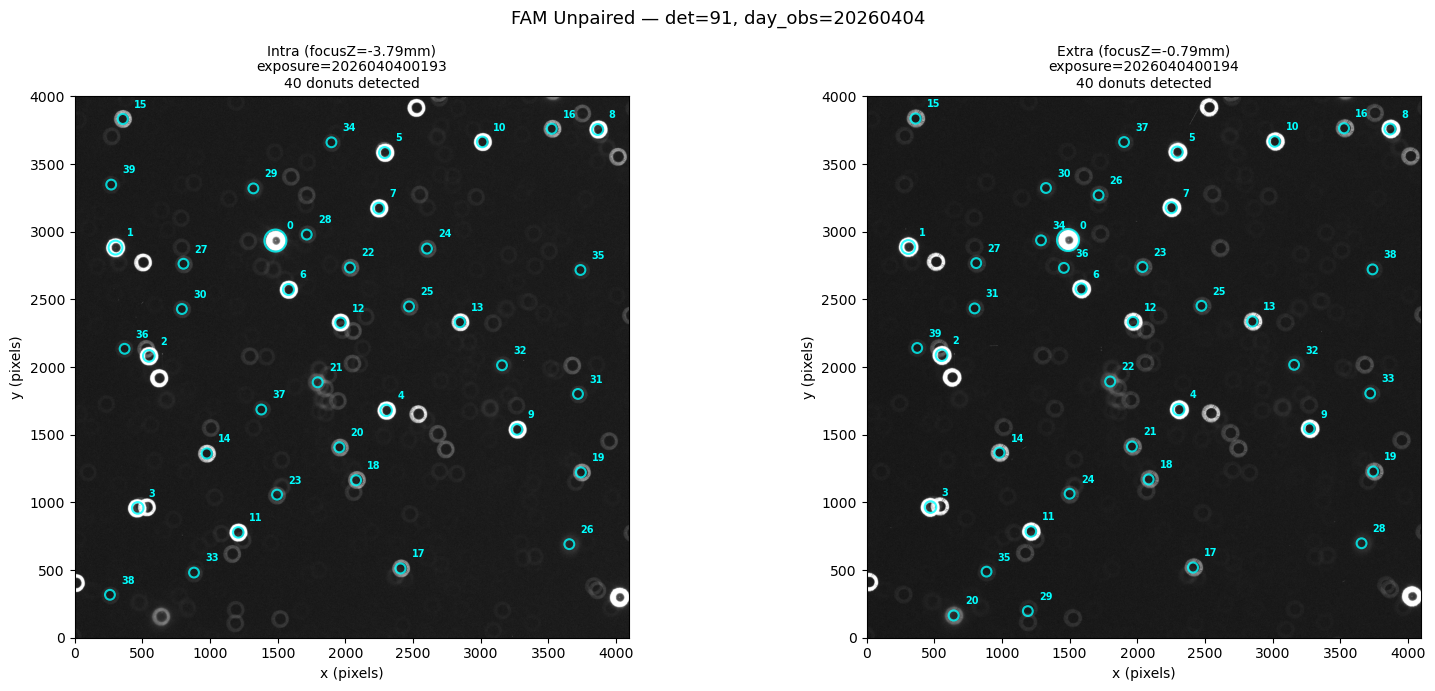

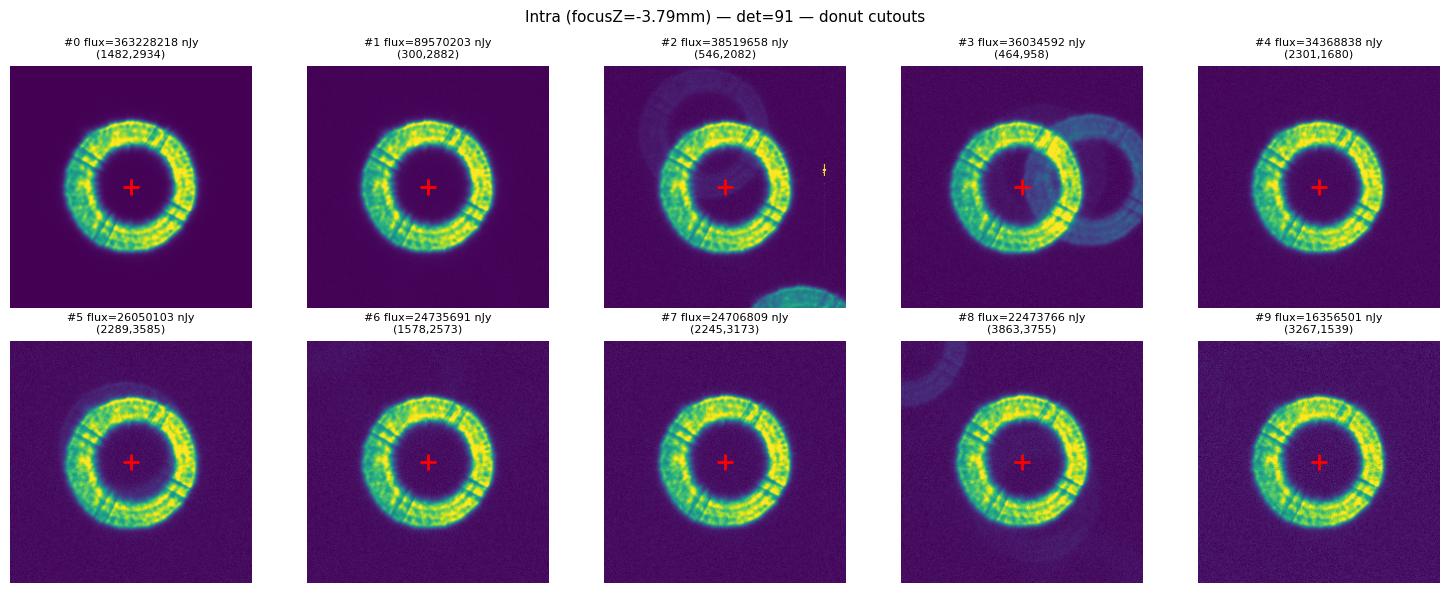

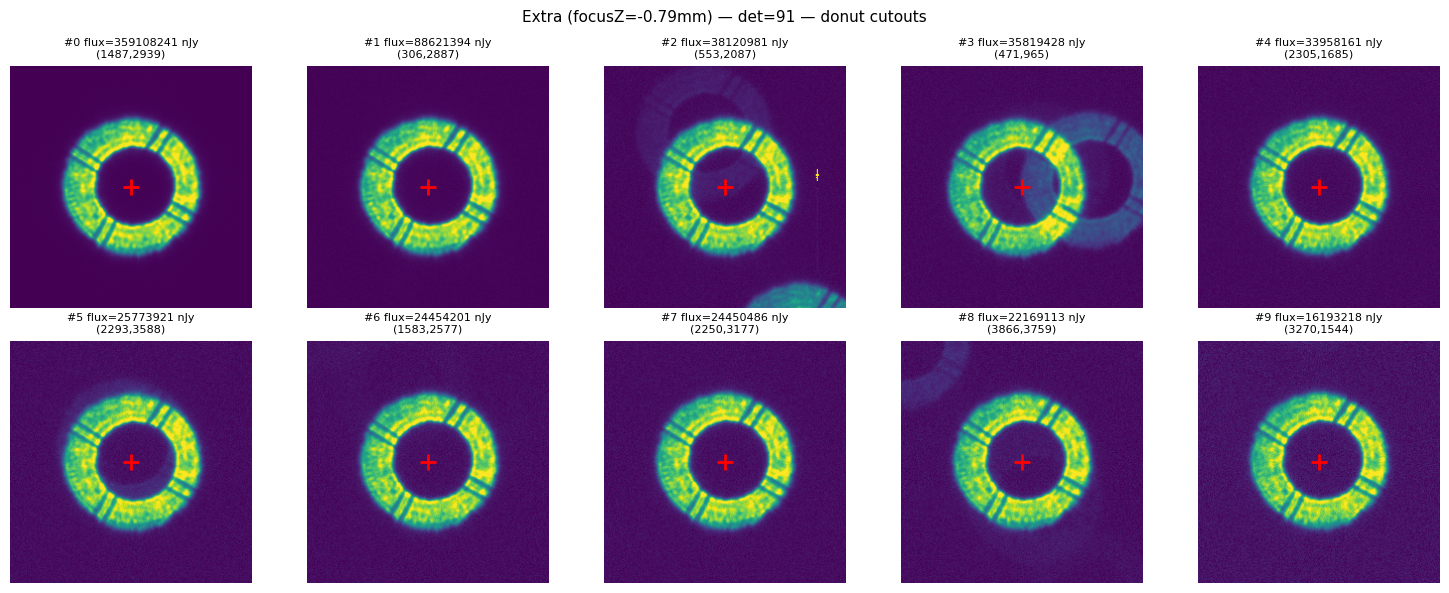

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from lsst.daf import butler as dafButler

butler = dafButler.Butler('/repo/main')
collection = 'u/scichris/test_FAM_unpaired_20260404_det91'
day_obs = 20260404

img_refs = list(butler.registry.queryDatasets(
    'post_isr_image', collections=[collection], day_obs=day_obs,
    where="instrument='LSSTCam'").expanded())

dt_refs = list(butler.registry.queryDatasets(
    'donutTable', collections=[collection], day_obs=day_obs,
    where="instrument='LSSTCam'").expanded())

# Sort both by visit to ensure matching order
img_refs = sorted(img_refs, key=lambda r: r.dataId['exposure'])
dt_refs = sorted(dt_refs, key=lambda r: r.dataId['visit'])

# Verify they match
for ir, dr in zip(img_refs, dt_refs):
    print(f"Image: exposure={ir.dataId['exposure']}  DonutTable: visit={dr.dataId['visit']}")

# Load
exposures = [butler.get(r) for r in img_refs]
donut_tables = [butler.get(r) for r in dt_refs]

# Determine intra/extra from relative focusZ
focus_values = [exp.visitInfo.focusZ for exp in exposures]
labels = []
for i, (exp, fz) in enumerate(zip(exposures, focus_values)):
    if fz == min(focus_values):
        label = "Intra"
    else:
        label = "Extra"
    labels.append(f"{label} (focusZ={fz:.2f}mm)")
    print(f"  exposure={exp.visitInfo.id} focusZ={fz:.3f} -> {label}")
    
# ── Plot 1: Full detector with donut positions ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, exp, dt, label, ref in zip(axes, exposures, donut_tables, labels, img_refs):
    img = exp.image.array
    vmin, vmax = np.percentile(img, [1, 99])

    ax.imshow(img, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)

    # Plot donut positions
    if len(dt) > 0:
        cx = dt['centroid_x']
        cy = dt['centroid_y']
        flux = dt['source_flux'].value

        # Size markers by flux
        sizes = 50 + 200 * (flux - flux.min()) / (flux.max() - flux.min() + 1)

        ax.scatter(cx, cy, s=sizes, facecolors='none', edgecolors='cyan',
                   linewidths=1.5, alpha=0.8)

        # Label each donut
        for i in range(len(dt)):
            ax.annotate(f"{i}", (cx[i], cy[i]),
                        xytext=(8, 8), textcoords='offset points',
                        fontsize=7, color='cyan', fontweight='bold')

    ax.set_title(f"{label}\nexposure={ref.dataId['exposure']}\n{len(dt)} donuts detected",
                 fontsize=10)
    ax.set_xlabel('x (pixels)')
    ax.set_ylabel('y (pixels)')

plt.suptitle(f'FAM Unpaired — det={img_refs[0].dataId["detector"]}, day_obs={day_obs}',
             fontsize=13)
plt.tight_layout()
plt.savefig('fam_unpaired_full_detector.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Zoomed cutouts of individual donuts ──
for exp, dt, label, ref in zip(exposures, donut_tables, labels, img_refs):
    if len(dt) == 0:
        continue

    n_donuts = min(len(dt), 10)
    ncols = min(5, n_donuts)
    nrows = (n_donuts + ncols - 1) // ncols
    stamp_size = 120  # pixels half-width

    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes[np.newaxis, :]
    elif ncols == 1:
        axes = axes[:, np.newaxis]

    img = exp.image.array
    h, w = img.shape

    for i in range(n_donuts):
        r, c = divmod(i, ncols)
        ax = axes[r, c]

        cx = int(dt['centroid_x'][i])
        cy = int(dt['centroid_y'][i])

        x0 = max(0, cx - stamp_size)
        x1 = min(w, cx + stamp_size)
        y0 = max(0, cy - stamp_size)
        y1 = min(h, cy + stamp_size)

        stamp = img[y0:y1, x0:x1]
        vmin_s, vmax_s = np.percentile(stamp, [1, 99])

        ax.imshow(stamp, cmap='viridis', origin='lower', vmin=vmin_s, vmax=vmax_s)
        # Mark center
        ax.plot(cx - x0, cy - y0, 'r+', markersize=12, markeredgewidth=2)

        donut_id = dt['donut_id'][i] if 'donut_id' in dt.colnames else f"{i}"
        ax.set_title(f"#{i} flux={dt['source_flux'][i]:.0f}\n({cx},{cy})", fontsize=8)
        ax.axis('off')

    # Hide unused
    for i in range(n_donuts, nrows * ncols):
        r, c = divmod(i, ncols)
        axes[r, c].axis('off')

    plt.suptitle(f'{label} — det={ref.dataId["detector"]} — donut cutouts', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'fam_unpaired_cutouts_{ref.dataId["exposure"]}.png', dpi=150, bbox_inches='tight')
    plt.show()

Ok, based on these tables,  we cutout donut stamps. Note: in this pipeline, the donut stamps have different names! It actually produces `donutStampsScienceSensor` rather than `donutStampsExtra` / `donutStampsIntra`... 

In [38]:

refs = list(butler.registry.queryDatasets(
    'donutStampsScienceSensor',
    collections=[collection], day_obs = day_obs,
    where=f"instrument='LSSTCam'").expanded())



In [39]:
stmp = butler.get(refs[0])

In [41]:
stmp[0]

DonutStamp(stamp_im=lsst.afw.image._maskedImage.MaskedImageF=(image=[[   2.0029297     3.3374023    -8.635742   ...   64.045166
   -17.509521     27.255615  ]
 [  80.6543       31.010742    -45.960205   ...   86.94995
    -9.953613     55.70923   ]
 [   2.2209473   -14.583496    174.84766    ... -117.21582
   -71.82373      20.39038   ]
 ...
 [  42.013184     20.476562    -32.89258    ... -134.5415
   -35.902832     32.248047  ]
 [ -55.540283    -18.72876    -122.09497    ...   17.820312
   -43.698242    -26.857178  ]
 [  52.6958        0.82250977  -22.91455    ...  -77.973145
    45.341797    -19.018066  ]],
mask=[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]], maskPlaneDict={'BAD': 0, 'BLEND': 15, 'CR': 3, 'CROSSTALK': 11, 'DETECTED': 5, 'DETECTED_NEGATIVE': 6, 'DONUT': 16, 'EDGE': 4, 'INTRP': 2, 'ITL_DIP': 12, 'NO_DATA': 8, 'PARTLY_VIGNETTED': 13, 'SAT': 1, 'STREAK': 10, 'SUSPECT': 7, 'UNMASKEDNAN': 14, 'VIGNETT

In [42]:
stmp[0].calcFieldXY()

(np.float64(-0.03142559136564824), np.float64(-0.18291305743595254))

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from lsst.daf import butler as dafButler

butler = dafButler.Butler('/repo/main')
collection = 'u/scichris/test_FAM_unpaired_20260404_det91'
day_obs = 20260404

stmp_refs = list(butler.registry.queryDatasets(
    'donutStampsScienceSensor',
    collections=[collection], day_obs=day_obs,
    where="instrument='LSSTCam'").expanded())

stmp_refs = sorted(stmp_refs, key=lambda r: r.dataId['visit'])

# Load stamps
stamps = [butler.get(r) for r in stmp_refs]

# Figure out intra/extra from defocal_type or focusZ
labels = []
for i, (stmp, ref) in enumerate(zip(stamps, stmp_refs)):
    dt = stmp[0].defocal_type if len(stmp) > 0 else "unknown"
    labels.append(dt)
    print(f"Visit {ref.dataId['visit']}: {len(stmp)} stamps, defocal_type='{dt}'")

# ── Check field positions ──
print(f"\n{'='*80}")
print(f"Field positions (degrees):")
print(f"{'type':>6} {'donut_id':>25} {'field_x':>10} {'field_y':>10} {'centroid_x':>10} {'centroid_y':>10}")
print(f"{'-'*80}")

field_positions = {}
for stmp_list, label, ref in zip(stamps, labels, stmp_refs):
    for i, s in enumerate(stmp_list):
        fx, fy = s.calcFieldXY()
        did = s.donut_id
        cx = s.centroid_position.x
        cy = s.centroid_position.y
        print(f"{label:>6} {did:>25} {fx:>10.4f} {fy:>10.4f} {cx:>10.1f} {cy:>10.1f}")

        # Group by index for pairing
        if i not in field_positions:
            field_positions[i] = {}
        field_positions[i][label] = (fx, fy, cx, cy, did)

# Check if pairs share the same field location
print(f"\n{'='*80}")
print(f"Pair comparison:")
for idx in sorted(field_positions.keys()):
    pos = field_positions[idx]
    if 'intra' in pos and 'extra' in pos:
        fx_i, fy_i, _, _, did_i = pos['intra']
        fx_e, fy_e, _, _, did_e = pos['extra']
        dx = fx_e - fx_i
        dy = fy_e - fy_i
        sep = np.sqrt(dx**2 + dy**2) * 3600  # to arcsec
        print(f"  Pair {idx}: intra=({fx_i:.4f},{fy_i:.4f}) extra=({fx_e:.4f},{fy_e:.4f})  "
              f"delta=({dx:.5f},{dy:.5f}) deg  sep={sep:.1f} arcsec")



Visit 2026040400193: 40 stamps, defocal_type='intra'
Visit 2026040400194: 40 stamps, defocal_type='extra'

Field positions (degrees):
  type                  donut_id    field_x    field_y centroid_x centroid_y
--------------------------------------------------------------------------------
 intra     2026040400193_091_000    -0.0314    -0.1829     1482.0     2935.0
 intra     2026040400193_091_001    -0.0971    -0.1858      300.0     2883.0
 intra     2026040400193_091_002    -0.0834    -0.2303      547.0     2082.0
 intra     2026040400193_091_003    -0.0882    -0.2928      460.0      958.0
 intra     2026040400193_091_004     0.0141    -0.2527     2301.0     1680.0
 intra     2026040400193_091_005     0.0135    -0.1468     2290.0     3584.0
 intra     2026040400193_091_006    -0.0260    -0.2030     1579.0     2573.0
 intra     2026040400193_091_007     0.0110    -0.1696     2246.0     3174.0
 intra     2026040400193_091_008     0.1009    -0.1373     3864.0     3756.0
 intra     2026

In [45]:
stamps

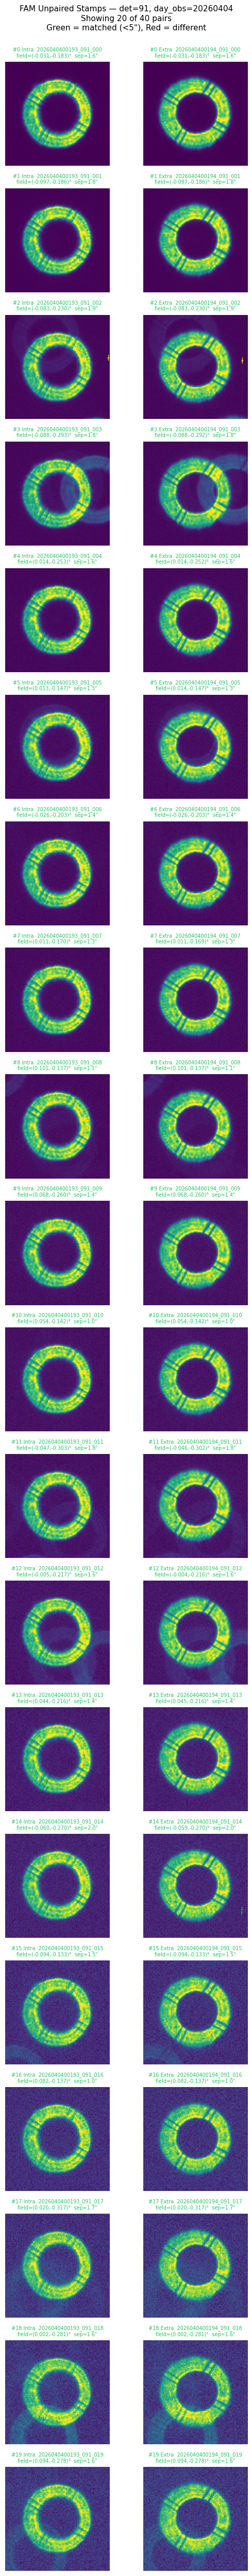

In [55]:
# ── Plot: Intra/Extra pairs side by side, color by field match ──
n_show = min(20, len(stamps[0]), len(stamps[1]))

fig, axes = plt.subplots(n_show, 2, figsize=(6, 2.5 * n_show))

for i in range(n_show):
    s_intra = stamps[0][i]
    s_extra = stamps[1][i]

    fx_i, fy_i = s_intra.calcFieldXY()
    fx_e, fy_e = s_extra.calcFieldXY()

    sep_arcsec = np.sqrt((fx_e - fx_i)**2 + (fy_e - fy_i)**2) * 3600
    matched = sep_arcsec < 5.0  # within 5 arcsec = same star
    color = '#22c55e' if matched else '#ef4444'

    for j, (s, label) in enumerate([(s_intra, 'Intra'), (s_extra, 'Extra')]):
        ax = axes[i, j]
        img = s.stamp_im.image.array

        vmin, vmax = np.percentile(img, [1, 99])
        ax.imshow(img, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)

        fx, fy = s.calcFieldXY()
        ax.set_title(f"#{i} {label}  {s.donut_id}\n"
                     f"field=({fx:.3f},{fy:.3f})°  sep={sep_arcsec:.1f}\"",
                     fontsize=7, color=color)
        ax.axis('off')

plt.suptitle(f'FAM Unpaired Stamps — det={stmp_refs[0].dataId["detector"]}, day_obs={day_obs}\n'
             f'Showing {n_show} of {min(len(stamps[0]), len(stamps[1]))} pairs\n'
             f'Green = matched (<5\"), Red = different',y=1.00,
             fontsize=11)
plt.tight_layout()
plt.savefig('fam_unpaired_stamps_paired.png', dpi=150, bbox_inches='tight')
plt.show()

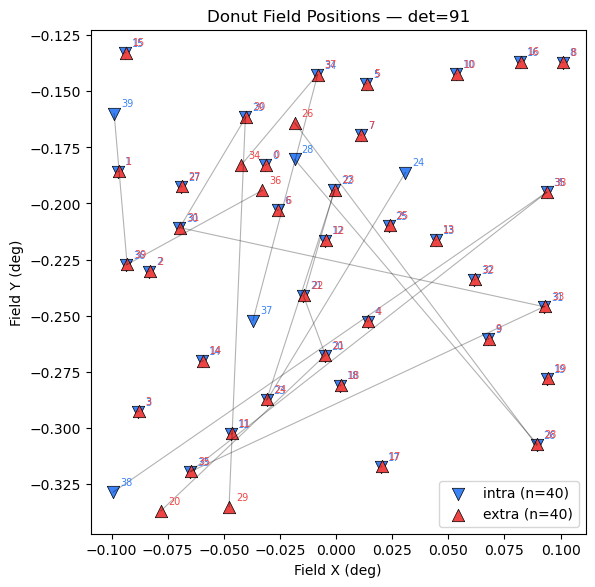

In [48]:

# ── Plot: Field positions on focal plane ──
fig, ax = plt.subplots(figsize=(6, 6))
colors = {'intra': '#3b82f6', 'extra': '#ef4444'}
markers = {'intra': 'v', 'extra': '^'}

for stmp_list, label in zip(stamps, labels):
    fxs = []
    fys = []
    for s in stmp_list:
        fx, fy = s.calcFieldXY()
        fxs.append(fx)
        fys.append(fy)
    ax.scatter(fxs, fys, c=colors.get(label, 'gray'), marker=markers.get(label, 'o'),
               s=80, label=f'{label} (n={len(fxs)})', edgecolors='k', linewidths=0.5)

    for i, s in enumerate(stmp_list):
        fx, fy = s.calcFieldXY()
        ax.annotate(f"{i}", (fx, fy), xytext=(5, 5), textcoords='offset points',
                    fontsize=7, color=colors.get(label, 'gray'))

# Draw lines between pairs
for idx in sorted(field_positions.keys()):
    pos = field_positions[idx]
    if 'intra' in pos and 'extra' in pos:
        ax.plot([pos['intra'][0], pos['extra'][0]],
                [pos['intra'][1], pos['extra'][1]],
                'k-', alpha=0.3, linewidth=0.8)

ax.set_xlabel('Field X (deg)')
ax.set_ylabel('Field Y (deg)')
ax.set_title(f'Donut Field Positions — det={stmp_refs[0].dataId["detector"]}')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('fam_unpaired_field_positions.png', dpi=150, bbox_inches='tight')
plt.show()

Given these stamps (and the associated metadata), we create the `donutQualityTable`: 

In [61]:

refs = list(butler.registry.queryDatasets(
    'donutQualityTable',
    collections=[collection], day_obs = day_obs,
    where=f"instrument='LSSTCam'").expanded())



In [62]:
refs

[DatasetRef(DatasetType('donutQualityTable', {band, instrument, day_obs, detector, physical_filter, visit}, AstropyQTable), {instrument: 'LSSTCam', detector: 91, visit: 2026040400193, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_unpaired_20260404_det91/20260512T225332Z', id=019e1e65-deed-7161-ab4f-176b041a00c7),
 DatasetRef(DatasetType('donutQualityTable', {band, instrument, day_obs, detector, physical_filter, visit}, AstropyQTable), {instrument: 'LSSTCam', detector: 91, visit: 2026040400194, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_unpaired_20260404_det91/20260512T225332Z', id=019e1e65-df06-78a9-8dd5-528750fe2dc0)]

In [63]:
dq = butler.get(refs[0])

There is one quality table per defocal type in this case:

In [67]:
dq[dq['FINAL_SELECT']]

SN,ENTROPY,FRAC_BAD_PIX,MAX_POWER_GRAD,SN_SELECT,ENTROPY_SELECT,FRAC_BAD_PIX_SELECT,MAX_POWER_GRAD_SELECT,RADIUS,FINAL_SELECT,DONUT_ID,DEFOCAL_TYPE
float64,float64,float64,float64,bool,bool,bool,bool,float64,bool,str21,str5
58421.140625,0.893817441417384,0.0,0.238659561981739,True,True,True,True,60.0,True,2026040400193_091_000,intra
48242.76953125,1.19595440454204,0.0,0.249798175681221,True,True,True,True,60.0,True,2026040400193_091_001,intra
35056.2890625,2.26557826730608,0.0,0.0127243961963812,True,True,True,True,60.0,True,2026040400193_091_003,intra
35073.08984375,1.96007420669055,0.0,0.232810086951928,True,True,True,True,60.0,True,2026040400193_091_004,intra
30579.2734375,2.32048916510304,0.0,0.200084600103425,True,True,True,True,60.0,True,2026040400193_091_005,intra
30031.015625,2.30357039067596,0.0,0.247653534939531,True,True,True,True,60.0,True,2026040400193_091_006,intra
30021.765625,2.24488396274583,0.0,0.248761495149858,True,True,True,True,60.0,True,2026040400193_091_007,intra
28377.072265625,2.50381396438956,0.0,0.27813897273625,True,True,True,True,60.0,True,2026040400193_091_008,intra
23551.4921875,2.65379848851609,0.0,0.257951969888015,True,True,True,True,60.0,True,2026040400193_091_009,intra


We get two sets of zernike tables as well:

In [12]:

refs = list(butler.registry.queryDatasets(
    'zernikes',
    collections=[collection], day_obs = day_obs,
    where=f"instrument='LSSTCam'").expanded())



In [13]:
refs

[DatasetRef(DatasetType('zernikes', {band, instrument, day_obs, detector, physical_filter, visit}, AstropyQTable), {instrument: 'LSSTCam', detector: 91, visit: 2026040400193, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_unpaired_20260404_det91/20260512T225332Z', id=019e1e65-deed-79bf-b13a-816878a95970),
 DatasetRef(DatasetType('zernikes', {band, instrument, day_obs, detector, physical_filter, visit}, AstropyQTable), {instrument: 'LSSTCam', detector: 91, visit: 2026040400194, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_unpaired_20260404_det91/20260512T225332Z', id=019e1e65-df06-76c9-9043-e59aa500b144)]

In [ ]:
Compare the retrieved Zernikes: 

In [69]:

refs = list(butler.registry.queryDatasets(
    'aggregateZernikesRaw',
    collections=[collection], day_obs = day_obs,
    where=f"instrument='LSSTCam'").expanded())



In [72]:
refs

[DatasetRef(DatasetType('aggregateZernikesRaw', {band, instrument, day_obs, physical_filter, visit}, AstropyTable), {instrument: 'LSSTCam', visit: 2026040400193, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_unpaired_20260404_det91/20260512T225332Z', id=019e1e65-df13-7113-9131-aeebbe30acea),
 DatasetRef(DatasetType('aggregateZernikesRaw', {band, instrument, day_obs, physical_filter, visit}, AstropyTable), {instrument: 'LSSTCam', visit: 2026040400194, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_unpaired_20260404_det91/20260512T225332Z', id=019e1e65-df12-7c5b-a239-7114b7bd4b5c)]

In [73]:
agg = butler.get(refs[0])

In [75]:
agg.meta['nollIndices']

array([ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22,
       23, 24, 25, 26])

Found 2 aggregateZernikesRaw refs
  visit=2026040400193: 20 rows, 16 used, nollIndices=[ 4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 22 23 24 25 26]
  visit=2026040400194: 20 rows, 14 used, nollIndices=[ 4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 22 23 24 25 26]
  visit=2026040400193 -> Intra (focusZ proxy=2026040400193)
  visit=2026040400194 -> Extra (focusZ proxy=2026040400194)


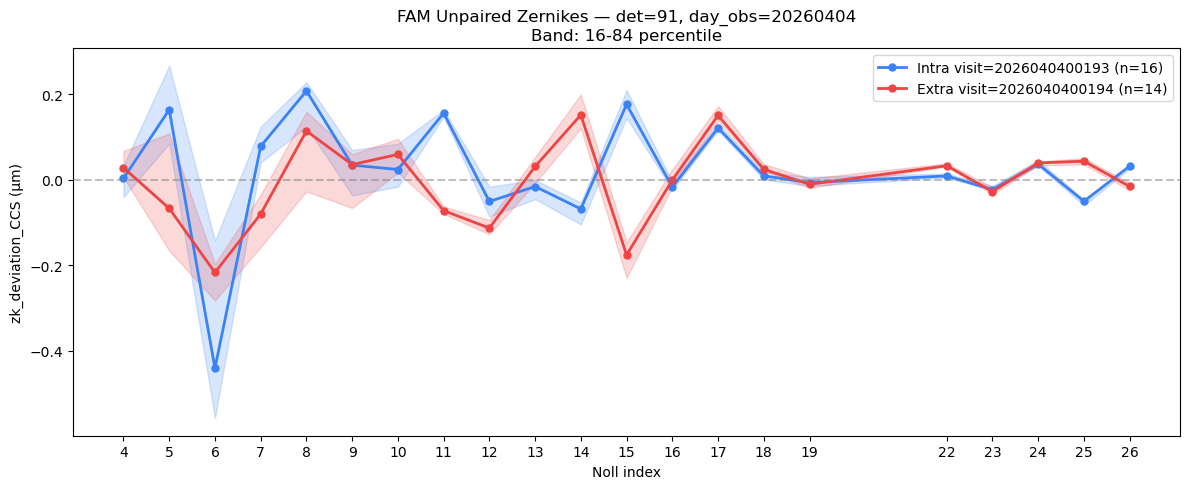

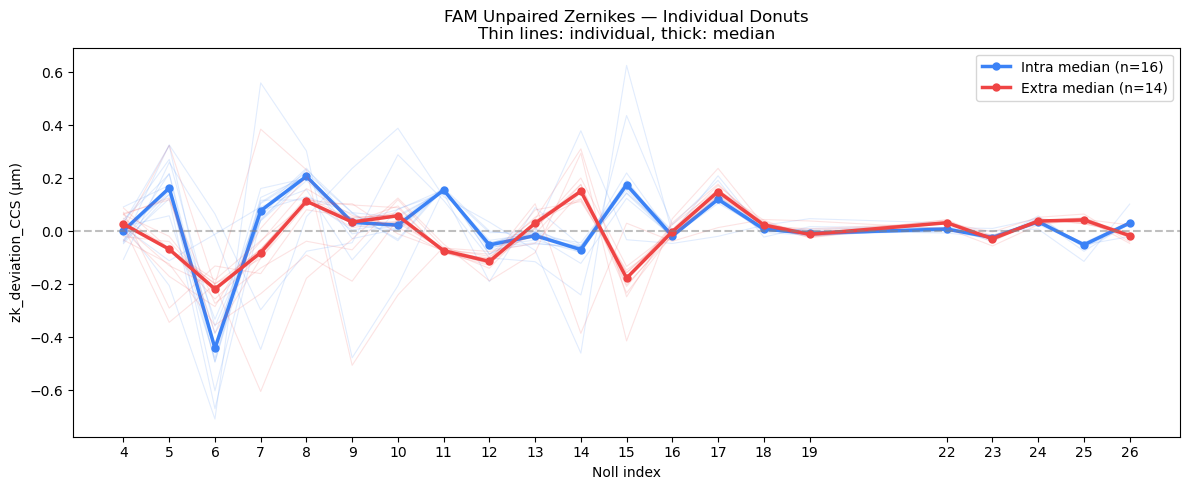

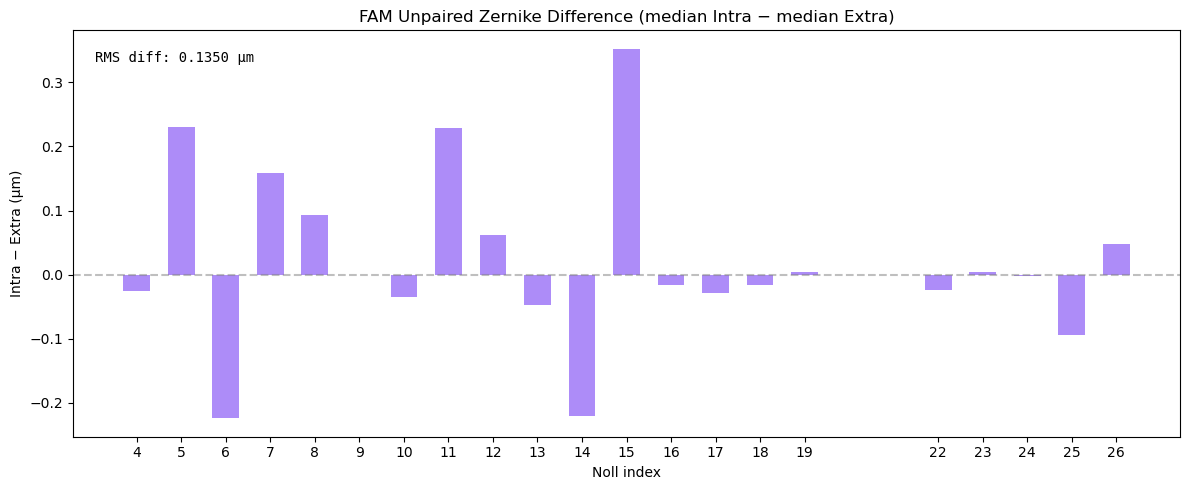


Summary: zk_deviation_CCS
  Noll    Intra median    Extra median        Diff      |Diff|
------------------------------------------------------------
Z   4          0.0028          0.0278     -0.0250      0.0250
Z   5          0.1633         -0.0675      0.2308      0.2308
Z   6         -0.4412         -0.2174     -0.2239      0.2239
Z   7          0.0777         -0.0804      0.1581      0.1581
Z   8          0.2074          0.1137      0.0937      0.0937
Z   9          0.0339          0.0351     -0.0012      0.0012
Z  10          0.0236          0.0588     -0.0353      0.0353
Z  11          0.1555         -0.0727      0.2282      0.2282
Z  12         -0.0512         -0.1135      0.0623      0.0623
Z  13         -0.0162          0.0306     -0.0468      0.0468
Z  14         -0.0687          0.1513     -0.2200      0.2200
Z  15          0.1760         -0.1763      0.3523      0.3523
Z  16         -0.0176         -0.0010     -0.0165      0.0165
Z  17          0.1209          0.1500     -

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from lsst.daf import butler as dafButler

butler = dafButler.Butler('/repo/main')
collection = 'u/scichris/test_FAM_unpaired_20260404_det91'
day_obs = 20260404

# Load aggregateZernikesRaw — one per visit
agg_refs = list(butler.registry.queryDatasets(
    'aggregateZernikesRaw',
    collections=[collection], day_obs=day_obs,
    where="instrument='LSSTCam'").expanded())

agg_refs = sorted(agg_refs, key=lambda r: r.dataId['visit'])
print(f"Found {len(agg_refs)} aggregateZernikesRaw refs")

agg_tables = {}
for ref in agg_refs:
    visit = ref.dataId['visit']
    tbl = butler.get(ref)
    agg_tables[visit] = tbl
    noll = tbl.meta['nollIndices']
    n_used = np.sum(tbl['used']) if 'used' in tbl.colnames else len(tbl)
    print(f"  visit={visit}: {len(tbl)} rows, {n_used} used, nollIndices={noll}")

visits = sorted(agg_tables.keys())
# Determine intra/extra from visit order (lower focusZ = intra)
visit_labels = {}
for v in visits:
    tbl = agg_tables[v]
    # Try to get focusZ from metadata
    meta = tbl.meta
    if 'focusZ' in meta:
        fz = meta['focusZ']
    else:
        fz = v  # fallback to visit number
    visit_labels[v] = fz

# More negative = intra
sorted_by_fz = sorted(visit_labels.items(), key=lambda x: x[1])
labels = {sorted_by_fz[0][0]: 'Intra', sorted_by_fz[1][0]: 'Extra'}
for v, lab in labels.items():
    print(f"  visit={v} -> {lab} (focusZ proxy={visit_labels[v]})")

zk_col = 'zk_deviation_CCS'
noll_indices = np.array(agg_tables[visits[0]].meta['nollIndices'])

# ── Plot 1: Snake comparison ──
fig, ax = plt.subplots(figsize=(12, 5))

colors = {'Intra': '#3b82f6', 'Extra': '#ef4444'}

for visit in visits:
    tbl = agg_tables[visit]
    label = labels[visit]
    mask = tbl['used']
    subset = tbl[mask]

    if len(subset) == 0:
        print(f"  {label}: no used donuts!")
        continue

    zk_array = np.array([row[zk_col] for row in subset])
    median_zk = np.nanmedian(zk_array, axis=0)
    q16 = np.nanpercentile(zk_array, 16, axis=0)
    q84 = np.nanpercentile(zk_array, 84, axis=0)

    color = colors[label]
    ax.fill_between(noll_indices, q16, q84, alpha=0.2, color=color)
    ax.plot(noll_indices, median_zk, 'o-', color=color, linewidth=2,
            markersize=5, label=f'{label} visit={visit} (n={len(subset)})')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Noll index')
ax.set_ylabel(f'{zk_col} (μm)')
ax.set_title(f'FAM Unpaired Zernikes — det={agg_refs[0].dataId["detector"] if "detector" in agg_refs[0].dataId else "91"}, day_obs={day_obs}\n'
             f'Band: 16-84 percentile')
ax.set_xticks(noll_indices)
ax.legend()
plt.tight_layout()
plt.savefig('fam_unpaired_zk_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Per-donut lines + median ──
fig, ax = plt.subplots(figsize=(12, 5))

for visit in visits:
    tbl = agg_tables[visit]
    label = labels[visit]
    mask = tbl['used']
    subset = tbl[mask]

    if len(subset) == 0:
        continue

    zk_array = np.array([row[zk_col] for row in subset])
    color = colors[label]

    for i in range(len(zk_array)):
        ax.plot(noll_indices, zk_array[i], '-', color=color, alpha=0.15, linewidth=0.8)

    median_zk = np.nanmedian(zk_array, axis=0)
    ax.plot(noll_indices, median_zk, 'o-', color=color, linewidth=2.5,
            markersize=5, label=f'{label} median (n={len(subset)})')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Noll index')
ax.set_ylabel(f'{zk_col} (μm)')
ax.set_title(f'FAM Unpaired Zernikes — Individual Donuts\n'
             f'Thin lines: individual, thick: median')
ax.set_xticks(noll_indices)
ax.legend()
plt.tight_layout()
plt.savefig('fam_unpaired_zk_individual.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Difference (Intra - Extra) ──
fig, ax = plt.subplots(figsize=(12, 5))

medians = {}
for visit in visits:
    tbl = agg_tables[visit]
    label = labels[visit]
    mask = tbl['used']
    subset = tbl[mask]
    if len(subset) > 0:
        medians[label] = np.nanmedian(np.array([row[zk_col] for row in subset]), axis=0)

if 'Intra' in medians and 'Extra' in medians:
    diff = medians['Intra'] - medians['Extra']
    rms = np.sqrt(np.nanmean(diff**2))

    ax.bar(noll_indices, diff, color='#8b5cf6', alpha=0.7, width=0.6)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.text(0.02, 0.95, f'RMS diff: {rms:.4f} μm', transform=ax.transAxes,
            fontsize=10, va='top', fontfamily='monospace')

ax.set_xlabel('Noll index')
ax.set_ylabel('Intra − Extra (μm)')
ax.set_title(f'FAM Unpaired Zernike Difference (median Intra − median Extra)')
ax.set_xticks(noll_indices)
plt.tight_layout()
plt.savefig('fam_unpaired_zk_diff.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ──
print(f"\n{'='*80}")
print(f"Summary: {zk_col}")
print(f"{'Noll':>6}  {'Intra median':>14}  {'Extra median':>14}  {'Diff':>10}  {'|Diff|':>10}")
print(f"{'-'*60}")
if 'Intra' in medians and 'Extra' in medians:
    for i, n in enumerate(noll_indices):
        d = medians['Intra'][i] - medians['Extra'][i]
        print(f"Z{n:>4}  {medians['Intra'][i]:>14.4f}  {medians['Extra'][i]:>14.4f}  {d:>10.4f}  {abs(d):>10.4f}")
    print(f"{'RMS':>6}  {'':>14}  {'':>14}  {rms:>10.4f}")

## 2) Run FAM paired to make input for the unpaired pipelines 

In [ ]:
Now this pipeline produces also `post_isr_image` and   `donutTable` but `donutStampsExtra` and `donutStampsIntra` 

In [78]:
collection = 'u/scichris/test_FAM_paired_20260404_det91'
butler = dafButler.Butler('/repo/main')
refs = list(butler.registry.queryDatasets(
    'post_isr_image',
    collections=[collection], day_obs = day_obs,
    where=f"instrument='LSSTCam'").expanded())



In [79]:
refs

[DatasetRef(DatasetType('post_isr_image', {band, instrument, day_obs, detector, group, physical_filter, exposure}, Exposure), {instrument: 'LSSTCam', detector: 91, exposure: 2026040400193, band: 'i', day_obs: 20260404, group: '2026-04-05T02:15:55.775#1', physical_filter: 'i_39'}, run='u/scichris/test_FAM_paired_20260404_det91/20260513T000019Z', id=019e1ea3-036a-77c3-9bfc-572192bffa84),
 DatasetRef(DatasetType('post_isr_image', {band, instrument, day_obs, detector, group, physical_filter, exposure}, Exposure), {instrument: 'LSSTCam', detector: 91, exposure: 2026040400194, band: 'i', day_obs: 20260404, group: '2026-04-05T02:15:55.775#1', physical_filter: 'i_39'}, run='u/scichris/test_FAM_paired_20260404_det91/20260513T000019Z', id=019e1ea3-036a-7b81-9fb0-31382e782753)]

In [80]:
refs = list(butler.registry.queryDatasets(
    'donutTable',
    collections=[collection], day_obs = day_obs,
    where=f"instrument='LSSTCam'").expanded())


In [81]:
refs

[DatasetRef(DatasetType('donutTable', {band, instrument, day_obs, detector, physical_filter, visit}, AstropyQTable), {instrument: 'LSSTCam', detector: 91, visit: 2026040400193, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_paired_20260404_det91/20260513T000019Z', id=019e1ea3-036b-7867-a866-cb739042b80d),
 DatasetRef(DatasetType('donutTable', {band, instrument, day_obs, detector, physical_filter, visit}, AstropyQTable), {instrument: 'LSSTCam', detector: 91, visit: 2026040400194, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_paired_20260404_det91/20260513T000019Z', id=019e1ea3-038b-72b0-a475-c04b57941ba0)]

We can similarly  plot the detected donuts as in the unpaired case, but probably the two catalogs are very similar, since the `post_isr_image` would be identical:

In [93]:

dt_refs_paired = list(butler.registry.queryDatasets(
    'donutTable', collections=['u/scichris/test_FAM_paired_20260404_det91'], day_obs=day_obs,
    where="instrument='LSSTCam' and visit = 2026040400193 ").expanded())

dt_refs_unpaired = list(butler.registry.queryDatasets(
    'donutTable', collections=['u/scichris/test_FAM_unpaired_20260404_det91'], day_obs=day_obs,
    where="instrument='LSSTCam' and visit = 2026040400193").expanded())

In [94]:
dt_refs_paired

[DatasetRef(DatasetType('donutTable', {band, instrument, day_obs, detector, physical_filter, visit}, AstropyQTable), {instrument: 'LSSTCam', detector: 91, visit: 2026040400193, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_paired_20260404_det91/20260513T000019Z', id=019e1ea3-036b-7867-a866-cb739042b80d)]

In [95]:
dt_refs_unpaired

[DatasetRef(DatasetType('donutTable', {band, instrument, day_obs, detector, physical_filter, visit}, AstropyQTable), {instrument: 'LSSTCam', detector: 91, visit: 2026040400193, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_unpaired_20260404_det91/20260512T225332Z', id=019e1e65-deb1-7116-bc95-f6d53eb5c03b)]

Paired:   40 donuts
Unpaired: 40 donuts

Paired columns: ['coord_ra', 'coord_dec', 'centroid_x', 'centroid_y', 'detector', 'source_flux', 'donut_id']
Unpaired columns: ['coord_ra', 'coord_dec', 'centroid_x', 'centroid_y', 'detector', 'source_flux', 'donut_id']

Donut position comparison:
 idx   paired_x   paired_y unpaired_x unpaired_y    sep_pix  match
-----------------------------------------------------------------
   0     1482.4     2934.9     1482.4     2934.9        0.0      ✓
   1      300.4     2882.9      300.4     2882.9        0.0      ✓
   2      546.9     2082.6      546.9     2082.6        0.0      ✓
   3      464.9      959.0      464.9      959.0        0.0      ✓
   4     2301.0     1680.1     2301.0     1680.1        0.0      ✓
   5     2289.6     3585.2     2289.6     3585.2        0.0      ✓
   6     1578.8     2573.1     1578.8     2573.1        0.0      ✓
   7     2245.9     3173.9     2245.9     3173.9        0.0      ✓
   8     3864.0     3755.8     3864.0     

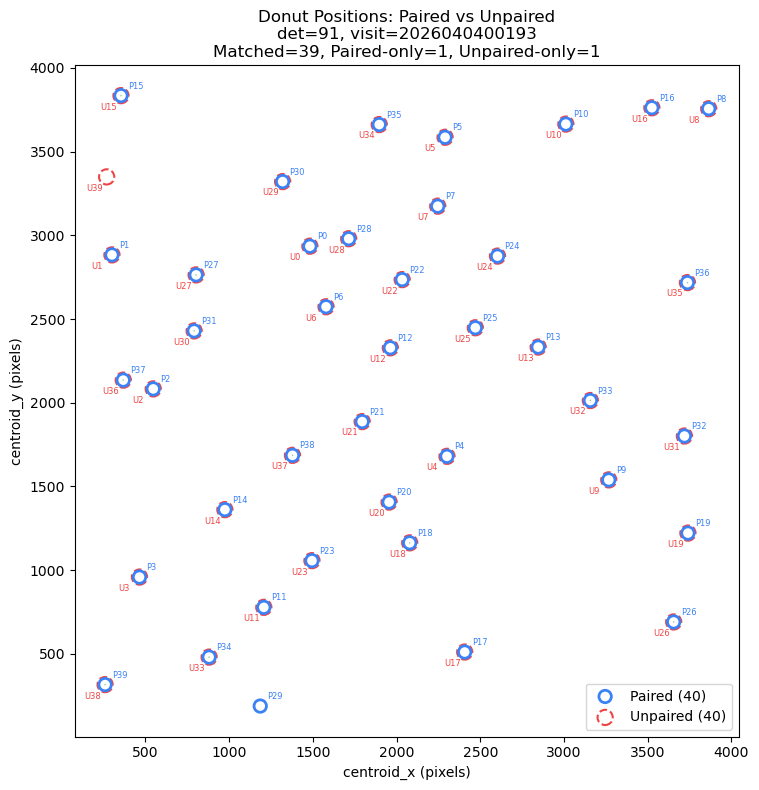

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from lsst.daf import butler as dafButler
from astropy.table import vstack

butler = dafButler.Butler('/repo/main')
day_obs = 20260404
visit = 2026040400193
det = 91

paired_coll = 'u/scichris/test_FAM_paired_20260404_det91'
unpaired_coll = 'u/scichris/test_FAM_unpaired_20260404_det91'

# ── Load donut tables ──
dt_paired = butler.get('donutTable', collections=[paired_coll],
                       instrument='LSSTCam', detector=det, visit=visit)
dt_unpaired = butler.get('donutTable', collections=[unpaired_coll],
                         instrument='LSSTCam', detector=det, visit=visit)

print(f"Paired:   {len(dt_paired)} donuts")
print(f"Unpaired: {len(dt_unpaired)} donuts")
print(f"\nPaired columns: {dt_paired.colnames}")
print(f"Unpaired columns: {dt_unpaired.colnames}")

# ── Compare donut positions ──
print(f"\n{'='*80}")
print(f"Donut position comparison:")
print(f"{'idx':>4} {'paired_x':>10} {'paired_y':>10} {'unpaired_x':>10} {'unpaired_y':>10} {'sep_pix':>10} {'match':>6}")
print(f"{'-'*65}")

# Cross-match by nearest position
matches = []
used_unpaired = set()
for i in range(len(dt_paired)):
    px, py = dt_paired['centroid_x'][i], dt_paired['centroid_y'][i]
    best_j = None
    best_dist = np.inf
    for j in range(len(dt_unpaired)):
        if j in used_unpaired:
            continue
        ux, uy = dt_unpaired['centroid_x'][j], dt_unpaired['centroid_y'][j]
        dist = np.sqrt((px - ux)**2 + (py - uy)**2)
        if dist < best_dist:
            best_dist = dist
            best_j = j

    matched = best_dist < 20  # within 20 pixels
    if matched:
        used_unpaired.add(best_j)
    matches.append({
        'paired_idx': i, 'unpaired_idx': best_j,
        'px': px, 'py': py,
        'ux': dt_unpaired['centroid_x'][best_j],
        'uy': dt_unpaired['centroid_y'][best_j],
        'sep': best_dist, 'matched': matched,
    })
    print(f"{i:>4} {px:>10.1f} {py:>10.1f} {dt_unpaired['centroid_x'][best_j]:>10.1f} "
          f"{dt_unpaired['centroid_y'][best_j]:>10.1f} {best_dist:>10.1f} {'✓' if matched else '✗':>6}")

n_matched = sum(1 for m in matches if m['matched'])
n_only_paired = len(dt_paired) - n_matched
n_only_unpaired = len(dt_unpaired) - n_matched
print(f"\nMatched: {n_matched}, Only in paired: {n_only_paired}, Only in unpaired: {n_only_unpaired}")

# ── Plot 1: Donut positions comparison ──
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(dt_paired['centroid_x'], dt_paired['centroid_y'],
           s=80, facecolors='none', edgecolors='#3b82f6', linewidths=2,
           label=f'Paired ({len(dt_paired)})', zorder=3)
ax.scatter(dt_unpaired['centroid_x'], dt_unpaired['centroid_y'],
           s=120, facecolors='none', edgecolors='#ef4444', linewidths=1.5,
           linestyle='--', label=f'Unpaired ({len(dt_unpaired)})', zorder=2)

# Draw match lines
for m in matches:
    if m['matched']:
        ax.plot([m['px'], m['ux']], [m['py'], m['uy']], 'g-', alpha=0.4, linewidth=1)

for i in range(len(dt_paired)):
    ax.annotate(f"P{i}", (dt_paired['centroid_x'][i], dt_paired['centroid_y'][i]),
                xytext=(5, 5), textcoords='offset points', fontsize=6, color='#3b82f6')
for j in range(len(dt_unpaired)):
    ax.annotate(f"U{j}", (dt_unpaired['centroid_x'][j], dt_unpaired['centroid_y'][j]),
                xytext=(-15, -10), textcoords='offset points', fontsize=6, color='#ef4444')

ax.set_xlabel('centroid_x (pixels)')
ax.set_ylabel('centroid_y (pixels)')
ax.set_title(f'Donut Positions: Paired vs Unpaired\ndet={det}, visit={visit}\n'
             f'Matched={n_matched}, Paired-only={n_only_paired}, Unpaired-only={n_only_unpaired}')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('paired_vs_unpaired_positions.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
Now we get `donutStampsExtra` and `donutStampsIntra` keyed under the extra-focal visit: 

In [103]:
refs = list(butler.registry.queryDatasets(
    'donutStampsExtra',
    collections=[paired_coll], day_obs = day_obs,
    where=f"instrument='LSSTCam'").expanded())


In [104]:
refs

[DatasetRef(DatasetType('donutStampsExtra', {band, instrument, day_obs, detector, physical_filter, visit}, StampsBase), {instrument: 'LSSTCam', detector: 91, visit: 2026040400194, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_paired_20260404_det91/20260513T000019Z', id=019e1ea3-039e-718a-b61a-dc44d4d2a0f0)]

In [105]:
refs = list(butler.registry.queryDatasets(
    'donutStampsIntra',
    collections=[paired_coll], day_obs = day_obs,
    where=f"instrument='LSSTCam'").expanded())


In [106]:
refs

[DatasetRef(DatasetType('donutStampsIntra', {band, instrument, day_obs, detector, physical_filter, visit}, StampsBase), {instrument: 'LSSTCam', detector: 91, visit: 2026040400194, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_paired_20260404_det91/20260513T000019Z', id=019e1ea3-039e-709c-8c9e-99f41d3af03d)]

as before, we could compare the donuts, but we know they would be pretty similar (since we start from similar donutTable)

Now we get one set of `zernikes` keyed under the extra-focal visit: 

In [107]:
refs = list(butler.registry.queryDatasets(
    'zernikes',
    collections=[paired_coll], day_obs = day_obs,
    where=f"instrument='LSSTCam'").expanded())


In [108]:
refs

[DatasetRef(DatasetType('zernikes', {band, instrument, day_obs, detector, physical_filter, visit}, AstropyQTable), {instrument: 'LSSTCam', detector: 91, visit: 2026040400194, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_paired_20260404_det91/20260513T000019Z', id=019e1ea3-03dd-76d8-9617-924add629f7c)]

Compare the paired zernikes  vs two sets of unpaired zernikes:

          Paired: 20 rows, 9 used
  Unpaired intra: 20 rows, 16 used
  Unpaired extra: 20 rows, 14 used


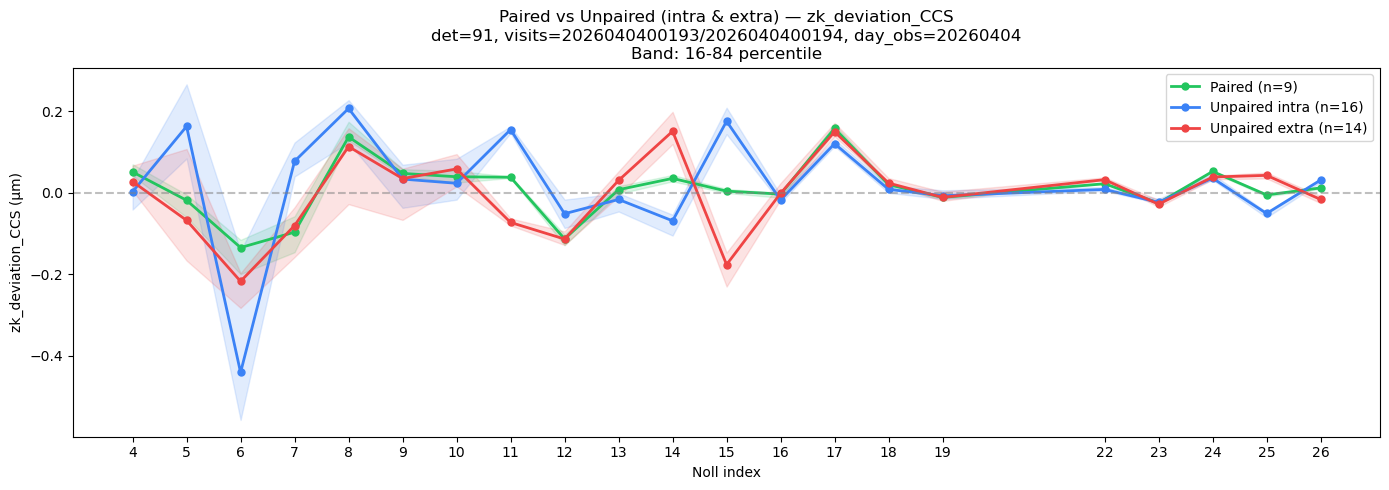

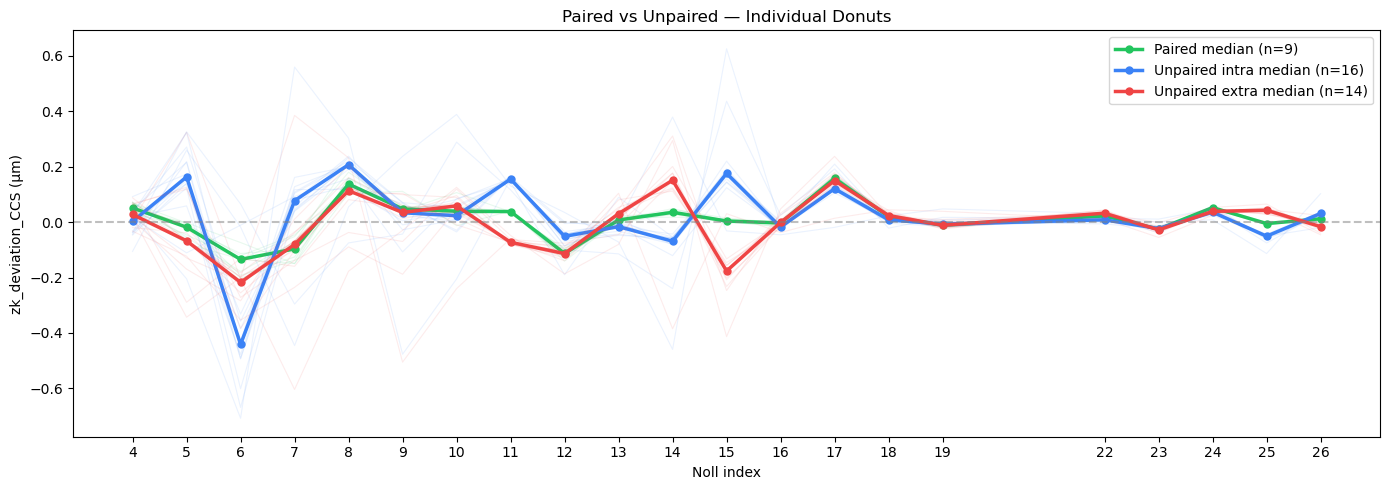

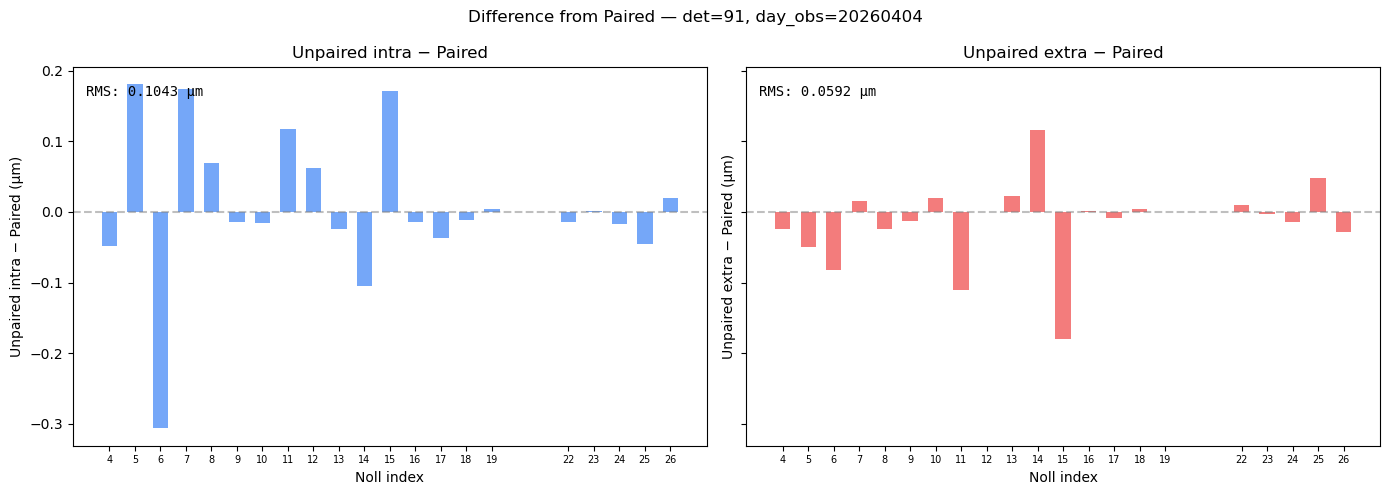

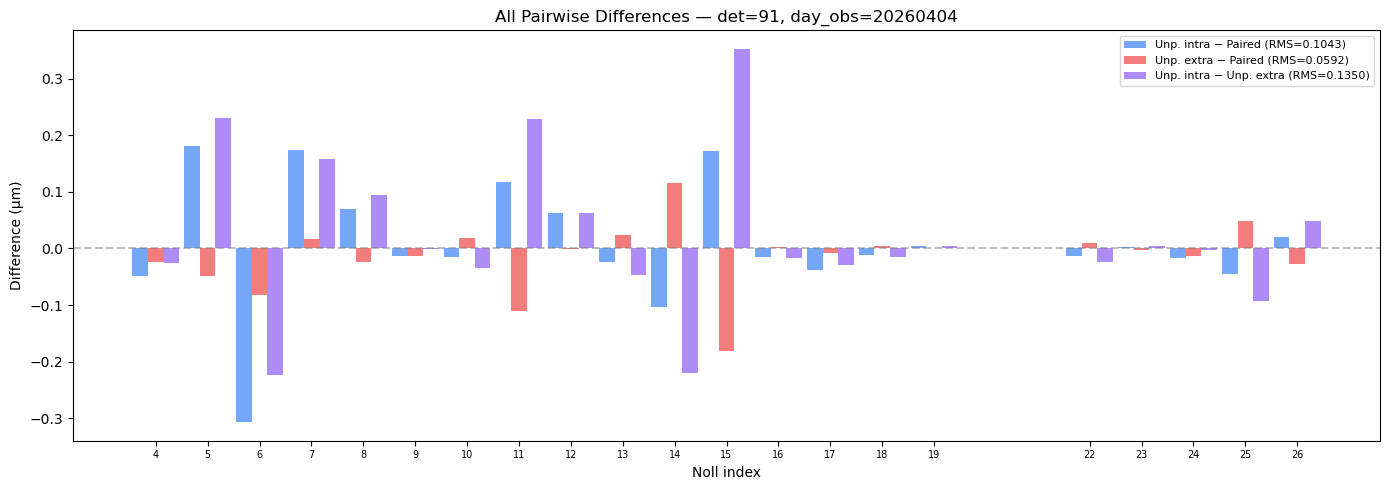


  Noll      Paired   Unp.intra   Unp.extra       I-P       E-P       I-E
---------------------------------------------------------------------------
Z   4      0.0513      0.0028      0.0278   -0.0485   -0.0235   -0.0250
Z   5     -0.0182      0.1633     -0.0675    0.1816   -0.0493    0.2308
Z   6     -0.1345     -0.4412     -0.2174   -0.3068   -0.0829   -0.2239
Z   7     -0.0965      0.0777     -0.0804    0.1742    0.0161    0.1581
Z   8      0.1375      0.2074      0.1137    0.0699   -0.0238    0.0937
Z   9      0.0478      0.0339      0.0351   -0.0139   -0.0126   -0.0012
Z  10      0.0396      0.0236      0.0588   -0.0160    0.0192   -0.0353
Z  11      0.0384      0.1555     -0.0727    0.1171   -0.1111    0.2282
Z  12     -0.1131     -0.0512     -0.1135    0.0618   -0.0004    0.0623
Z  13      0.0078     -0.0162      0.0306   -0.0240    0.0228   -0.0468
Z  14      0.0356     -0.0687      0.1513   -0.1043    0.1158   -0.2200
Z  15      0.0042      0.1760     -0.1763    0.1718   -0.1

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from lsst.daf import butler as dafButler

butler = dafButler.Butler('/repo/main')
day_obs = 20260404
det = 91
visit_intra = 2026040400193
visit_extra = 2026040400194

paired_coll = 'u/scichris/test_FAM_paired_20260404_det91'
unpaired_coll = 'u/scichris/test_FAM_unpaired_20260404_det91'

zk_col = 'zk_deviation_CCS'

# ── Load all three sets ──
# Paired: stored under extra visit
agg_paired = butler.get('aggregateZernikesRaw', collections=[paired_coll],
                        instrument='LSSTCam', visit=visit_extra)

# Unpaired intra: stored under intra visit
agg_unpaired_intra = butler.get('aggregateZernikesRaw', collections=[unpaired_coll],
                                instrument='LSSTCam', visit=visit_intra)

# Unpaired extra: stored under extra visit
agg_unpaired_extra = butler.get('aggregateZernikesRaw', collections=[unpaired_coll],
                                instrument='LSSTCam', visit=visit_extra)

noll_indices = np.array(agg_paired.meta['nollIndices'])

for label, tbl in [('Paired', agg_paired),
                    ('Unpaired intra', agg_unpaired_intra),
                    ('Unpaired extra', agg_unpaired_extra)]:
    n_used = np.sum(tbl['used'])
    print(f"{label:>16}: {len(tbl)} rows, {n_used} used")

# Filter to used
zk_paired = np.array([row[zk_col] for row in agg_paired[agg_paired['used']]])
zk_unp_intra = np.array([row[zk_col] for row in agg_unpaired_intra[agg_unpaired_intra['used']]])
zk_unp_extra = np.array([row[zk_col] for row in agg_unpaired_extra[agg_unpaired_extra['used']]])

datasets = {
    'Paired': zk_paired,
    'Unpaired intra': zk_unp_intra,
    'Unpaired extra': zk_unp_extra,
}

colors = {
    'Paired': '#22c55e',
    'Unpaired intra': '#3b82f6',
    'Unpaired extra': '#ef4444',
}

# ── Plot 1: Snake comparison all three ──
fig, ax = plt.subplots(figsize=(14, 5))

for label, zk_array in datasets.items():
    if len(zk_array) == 0:
        continue
    median_zk = np.nanmedian(zk_array, axis=0)
    q16 = np.nanpercentile(zk_array, 16, axis=0)
    q84 = np.nanpercentile(zk_array, 84, axis=0)

    color = colors[label]
    ax.fill_between(noll_indices, q16, q84, alpha=0.15, color=color)
    ax.plot(noll_indices, median_zk, 'o-', color=color, linewidth=2,
            markersize=5, label=f'{label} (n={len(zk_array)})')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Noll index')
ax.set_ylabel(f'{zk_col} (μm)')
ax.set_title(f'Paired vs Unpaired (intra & extra) — {zk_col}\n'
             f'det={det}, visits={visit_intra}/{visit_extra}, day_obs={day_obs}\n'
             f'Band: 16-84 percentile')
ax.set_xticks(noll_indices)
ax.legend()
plt.tight_layout()
plt.savefig('paired_vs_unpaired_3way_snake.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Individual donuts + median ──
fig, ax = plt.subplots(figsize=(14, 5))

for label, zk_array in datasets.items():
    if len(zk_array) == 0:
        continue
    color = colors[label]
    for i in range(len(zk_array)):
        ax.plot(noll_indices, zk_array[i], '-', color=color, alpha=0.1, linewidth=0.8)
    median_zk = np.nanmedian(zk_array, axis=0)
    ax.plot(noll_indices, median_zk, 'o-', color=color, linewidth=2.5,
            markersize=5, label=f'{label} median (n={len(zk_array)})')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Noll index')
ax.set_ylabel(f'{zk_col} (μm)')
ax.set_title(f'Paired vs Unpaired — Individual Donuts')
ax.set_xticks(noll_indices)
ax.legend()
plt.tight_layout()
plt.savefig('paired_vs_unpaired_3way_individual.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Differences relative to paired ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

med_paired = np.nanmedian(zk_paired, axis=0) if len(zk_paired) > 0 else None

for ax, (label, zk_array) in zip(axes, [('Unpaired intra', zk_unp_intra),
                                         ('Unpaired extra', zk_unp_extra)]):
    if med_paired is not None and len(zk_array) > 0:
        med_unp = np.nanmedian(zk_array, axis=0)
        diff = med_unp - med_paired
        rms = np.sqrt(np.nanmean(diff**2))

        ax.bar(noll_indices, diff, color=colors[label], alpha=0.7, width=0.6)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.text(0.02, 0.95, f'RMS: {rms:.4f} μm', transform=ax.transAxes,
                fontsize=10, va='top', fontfamily='monospace')

    ax.set_xlabel('Noll index')
    ax.set_ylabel(f'{label} − Paired (μm)')
    ax.set_title(f'{label} − Paired')
    ax.set_xticks(noll_indices)
    ax.tick_params(axis='x', labelsize=7)

plt.suptitle(f'Difference from Paired — det={det}, day_obs={day_obs}', fontsize=12)
plt.tight_layout()
plt.savefig('paired_vs_unpaired_3way_diff.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 4: All three differences in one plot ──
fig, ax = plt.subplots(figsize=(14, 5))

if med_paired is not None:
    # Unpaired intra vs paired
    if len(zk_unp_intra) > 0:
        diff_intra = np.nanmedian(zk_unp_intra, axis=0) - med_paired
        ax.bar(noll_indices - 0.3, diff_intra, 0.3, color=colors['Unpaired intra'],
               alpha=0.7, label=f'Unp. intra − Paired (RMS={np.sqrt(np.nanmean(diff_intra**2)):.4f})')

    # Unpaired extra vs paired
    if len(zk_unp_extra) > 0:
        diff_extra = np.nanmedian(zk_unp_extra, axis=0) - med_paired
        ax.bar(noll_indices, diff_extra, 0.3, color=colors['Unpaired extra'],
               alpha=0.7, label=f'Unp. extra − Paired (RMS={np.sqrt(np.nanmean(diff_extra**2)):.4f})')

    # Unpaired intra vs unpaired extra
    if len(zk_unp_intra) > 0 and len(zk_unp_extra) > 0:
        diff_ie = np.nanmedian(zk_unp_intra, axis=0) - np.nanmedian(zk_unp_extra, axis=0)
        ax.bar(noll_indices + 0.3, diff_ie, 0.3, color='#8b5cf6',
               alpha=0.7, label=f'Unp. intra − Unp. extra (RMS={np.sqrt(np.nanmean(diff_ie**2)):.4f})')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Noll index')
ax.set_ylabel('Difference (μm)')
ax.set_title(f'All Pairwise Differences — det={det}, day_obs={day_obs}')
ax.set_xticks(noll_indices)
ax.tick_params(axis='x', labelsize=7)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('paired_vs_unpaired_3way_alldiffs.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ──
print(f"\n{'='*90}")
print(f"{'Noll':>6}  {'Paired':>10}  {'Unp.intra':>10}  {'Unp.extra':>10}  "
      f"{'I-P':>8}  {'E-P':>8}  {'I-E':>8}")
print(f"{'-'*75}")
if med_paired is not None:
    med_i = np.nanmedian(zk_unp_intra, axis=0) if len(zk_unp_intra) > 0 else np.full_like(med_paired, np.nan)
    med_e = np.nanmedian(zk_unp_extra, axis=0) if len(zk_unp_extra) > 0 else np.full_like(med_paired, np.nan)
    for i, n in enumerate(noll_indices):
        di = med_i[i] - med_paired[i]
        de = med_e[i] - med_paired[i]
        die = med_i[i] - med_e[i]
        print(f"Z{n:>4}  {med_paired[i]:>10.4f}  {med_i[i]:>10.4f}  {med_e[i]:>10.4f}  "
              f"{di:>8.4f}  {de:>8.4f}  {die:>8.4f}")
    rms_ip = np.sqrt(np.nanmean((med_i - med_paired)**2))
    rms_ep = np.sqrt(np.nanmean((med_e - med_paired)**2))
    rms_ie = np.sqrt(np.nanmean((med_i - med_e)**2))
    print(f"{'RMS':>6}  {'':>10}  {'':>10}  {'':>10}  {rms_ip:>8.4f}  {rms_ep:>8.4f}  {rms_ie:>8.4f}")

As we can see, the paired estimate is much closer to the unpaired extra than to the unpaired intra-focal estimation.

## 3) Use the paired stamps as input for the unpaired pipelines

These pipelines (`lsstCamScienceSensorUSDF_UnpairedDanishExtra.yaml` and `lsstCamScienceSensorUSDF_UnpairedDanishIntra.yaml`) do not run ISR - instead, they use as input available donutStampsExtra (or donutStampsIntra), and run wavefront estimation:

check the output - now it's called "zernikesExtra":

In [112]:
refs = list(butler.registry.queryDatasets(
    'zernikesExtra',
    collections=['u/scichris/test_FAM_unpaired_20260404_det91_extra'], day_obs = day_obs,
    where=f"instrument='LSSTCam'").expanded())


In [114]:
refs

[DatasetRef(DatasetType('zernikesExtra', {band, instrument, day_obs, detector, physical_filter, visit}, AstropyQTable), {instrument: 'LSSTCam', detector: 91, visit: 2026040400194, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_unpaired_20260404_det91_extra/20260513T003822Z', id=019e1ec5-ad89-7dd3-9ec1-217c5a0ba4fb)]

In [ ]:
similarly for intra-focal: 

check the output:

In [117]:
refs = list(butler.registry.queryDatasets(
    'zernikesIntra',
    collections=['u/scichris/test_FAM_unpaired_20260404_det91_intra'], day_obs = day_obs,
    where=f"instrument='LSSTCam'").expanded())


In [118]:
refs

[DatasetRef(DatasetType('zernikesIntra', {band, instrument, day_obs, detector, physical_filter, visit}, AstropyQTable), {instrument: 'LSSTCam', detector: 91, visit: 2026040400194, band: 'i', day_obs: 20260404, physical_filter: 'i_39'}, run='u/scichris/test_FAM_unpaired_20260404_det91_intra/20260513T004226Z', id=019e1ec9-628e-7ba5-9cf0-e62288485e28)]

Now given that the donuts are (almost) the same, the `zernikesIntra` (or `aggregateZernikesRawIntra`) should be identical to `aggregateZernikesRaw` from the intra-focal unpaired pipeline (same for extra-focal)

In [123]:
len(agg_new_extra.meta['nollIndices'])

25

In [125]:
len(agg_unp_extra.meta['nollIndices'])

21

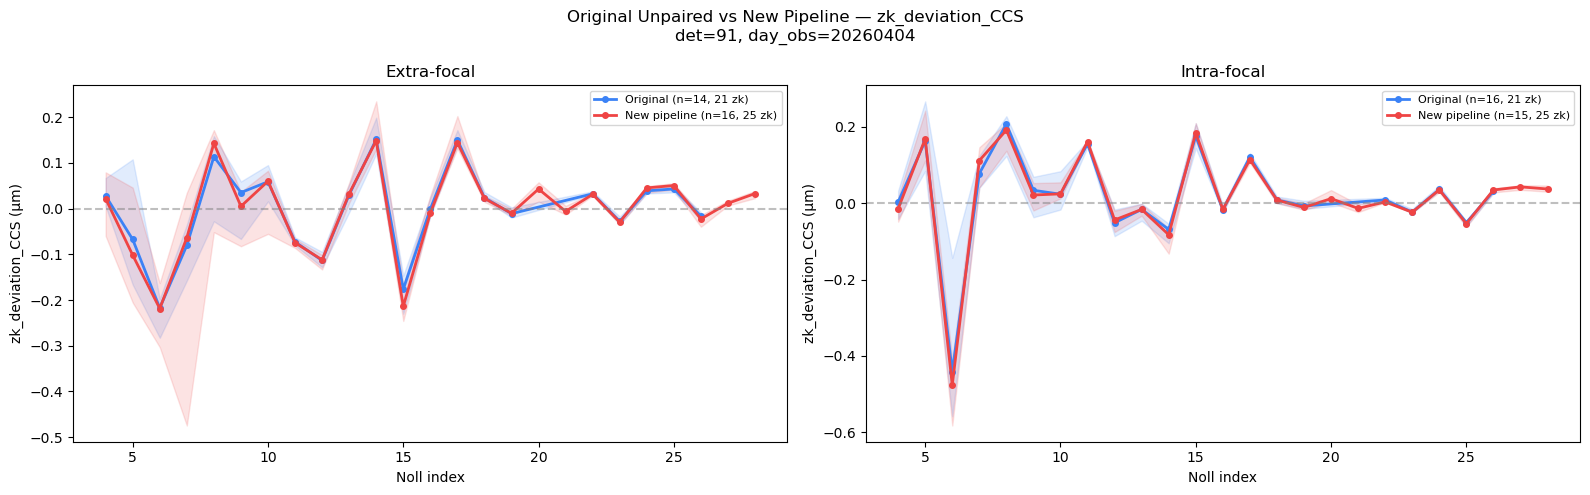

In [126]:
# ── Plot 1: Snake comparison ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (zk_orig, zk_new, tbl_orig, tbl_new, title) in zip(axes, [
    (zk_unp_extra, zk_new_extra, agg_unp_extra, agg_new_extra, 'Extra-focal'),
    (zk_unp_intra, zk_new_intra, agg_unp_intra, agg_new_intra, 'Intra-focal'),
]):
    for label, zk_array, tbl, color in [
        ('Original', zk_orig, tbl_orig, '#3b82f6'),
        ('New pipeline', zk_new, tbl_new, '#ef4444'),
    ]:
        if len(zk_array) == 0:
            continue
        noll = np.array(tbl.meta['nollIndices'])
        median_zk = np.nanmedian(zk_array, axis=0)
        q16 = np.nanpercentile(zk_array, 16, axis=0)
        q84 = np.nanpercentile(zk_array, 84, axis=0)

        ax.fill_between(noll, q16, q84, alpha=0.15, color=color)
        ax.plot(noll, median_zk, 'o-', color=color, linewidth=2,
                markersize=4, label=f'{label} (n={len(zk_array)}, {len(noll)} zk)')

    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Noll index')
    ax.set_ylabel(f'{zk_col} (μm)')
    ax.set_title(f'{title}')
    ax.legend(fontsize=8)

plt.suptitle(f'Original Unpaired vs New Pipeline — {zk_col}\ndet={det}, day_obs={day_obs}', fontsize=12)
plt.tight_layout()
plt.show()

Currently the two pipelines ("regular" unpaired vs "derived" unpaired) fit different Noll indices because 
                             `$DONUT_VIZ_DIR/pipelines/production/lsstcam_usdf/lsstCamScienceSensorUSDF_UnpairedDanish.yaml ` inherits from 
`$DONUT_VIZ_DIR/pipelines/production/lsstCamRapidAnalysisPipeline_UnpairedDanish.yaml`  which imports `$DONUT_VIZ_DIR/pipelines/_ingredients/wepDirectDetectUnpairedPipeline.yaml` setting explicitly 

```    
      estimateZernikes.nollIndices:
        [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]
      estimateZernikes.saveHistory: False
      estimateZernikes.lstsqKwargs:
        ftol: 1.0e-3
        xtol: 1.0e-3
        gtol: 1.0e-3
        max_nfev: 30
        verbose: 2
        x_scale: 'jac'
```